In [2]:
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize, LogNorm
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import scqubits
from tqdm import tqdm
from IPython.display import clear_output
from functools import partial
import matplotlib

from CoupledQuantumSystems.noise import second_order_derivative,first_order_derivative,get_fluxonium_frequency,diel_spectral_density, one_over_f_spectral_density,T_phi

# 1. Sweep temp, get T1 of f->e, e->f, e->g, g->e

In [36]:
tangent = 4e-6
eta = 1e-6

EJ = 4
EC = EJ/2.7
EL = EJ/45

UIFQ = scqubits.Fluxonium(EJ = EJ,EC =EC,EL = EL, cutoff =110,flux = 0,truncated_dim=20)
element_table = UIFQ.matrixelement_table('phi_operator',evals_count=3)
ef_element = np.abs(element_table[1,2]) 
ge_element = np.abs(element_table[0,1]) 

ef_freq = (UIFQ.eigenvals()[2]-UIFQ.eigenvals()[1]) * 2 * np.pi
ge_freq = (UIFQ.eigenvals()[1]-UIFQ.eigenvals()[0]) * 2 * np.pi

temp_in_mK_list = np.array([0,10,20,30,40,50])

diel_T1_array = np.zeros(shape = (4,len(temp_in_mK_list)),dtype='float')
one_overf_T1_array = np.zeros(shape = (4,len(temp_in_mK_list)),dtype='float')
T1_array = np.zeros(shape = (4,len(temp_in_mK_list)),dtype='float')

def get_data(temp_in_mK):

    tangent_ref = tangent
    one_over_f_flux_noise_amplitude = eta

    UIFQ_dielectric_lifetime = 1 / (np.abs(ef_element)**2 * diel_spectral_density(UIFQ_freq, EC,temp_in_mK,tangent_ref)) / 1e6
    UIFQ_one_over_f_loss_lifetime = 1 / (np.abs(ef_element)**2 * one_over_f_spectral_density(UIFQ_freq, EL,one_over_f_flux_noise_amplitude ))  / 1e6

    return UIFQ_dielectric_lifetime, UIFQ_one_over_f_loss_lifetime 

# for EJoverEC in tqdm(np.linspace(1,8,100),desc='looping'):
#     UIFQ_dielectric_lifetime, UIFQ_one_over_f_loss_lifetime, gf_dephasing_lifetime, gf_derivative = get_data(EJoverEC)
#     UIFQ_T1 =1/(1/UIFQ_dielectric_lifetime + 1/UIFQ_one_over_f_loss_lifetime)

#     UIFQ_diel_T1_array.append(UIFQ_dielectric_lifetime)
#     UIFQ_1overf_T1_array.append(UIFQ_one_over_f_loss_lifetime)
#     UIFQ_T1_array.append(UIFQ_T1)
#     gf_Tphi_array.append(gf_dephasing_lifetime)
#     derivative_array.append(gf_derivative)

# import pickle

# # Create a dictionary to store the lists
# data_to_store = {
#     'UIFQ_diel_T1_array': UIFQ_diel_T1_array,
#     'UIFQ_1overf_T1_array': UIFQ_1overf_T1_array,
#     'UIFQ_T1_array': UIFQ_T1_array,
#     'gf_Tphi_array': gf_Tphi_array,
#     'derivative_array':derivative_array
# }

# # Save the dictionary to a pickle file
# with open('gf-data.pkl', 'wb') as f:
#     pickle.dump(data_to_store, f)

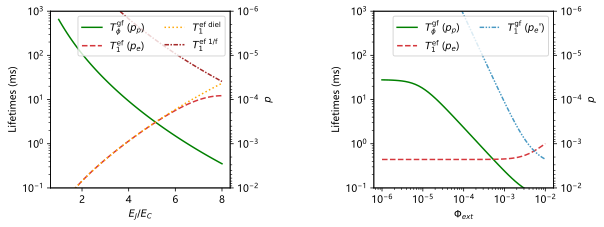

In [43]:
fig = plt.figure(figsize=(10, 3)) 
gs0 = fig.add_gridspec(nrows=1, ncols=1,left=0.15, right=0.4,bottom=0.15,top = 0.97)
gs1 = fig.add_gridspec(nrows=1, ncols=1,left=0.6, right=0.85,bottom=0.15,top = 0.97)


################################################
#
#   subplot 1 
#
################################################
ax = fig.add_subplot(gs0[0])


ax.plot(np.linspace(1,8,100), gf_Tphi_array, color= 'green',label = rf'$T_\phi^\text{{gf}}$ ($p_p$)',linestyle='-')
ax.plot(np.linspace(1,8,100), UIFQ_T1_array, color= '#d5373d',label = rf'$T_1^\text{{ef}}$ ($p_e$)',linestyle='--')

ax.plot(np.linspace(1,8,100), UIFQ_diel_T1_array, color= 'orange',label = rf'$T_1^\text{{ef diel}}$',linestyle=':')
ax.plot(np.linspace(1,8,100), UIFQ_1overf_T1_array, color= 'brown',label = rf'$T_1^\text{{ef 1/f}}$',linestyle=(0,(3,1,1,1)))

ymin = 1e-1
ymax = 1e3
ax.set_ylim(ymin, ymax)

ax2 = ax.twinx()
ax2.set_ylabel(r'$p$')
ax2.set_ylim(1e-3/ymin,1e-3/ymax)
ax2.set_yscale('log')

ax.set_yscale('log')
ax.set_xlabel(r'$E_J/E_C$')
ax.set_ylabel(r'Lifetimes (ms)')
ax.legend(ncol = 2,loc='upper right')

################################################
#
#   subplot 2
#
################################################

ax = fig.add_subplot(gs1[0])

ax.plot( flux_array, gf_Tphi_array_sweep_flux, color= 'green',label = rf'$T_\phi^\text{{gf}}$ ($p_p$)',linestyle='-')
ax.plot( flux_array, UIFQ_T1_array_sweep_flux, color= '#d5373d',label = rf'$T_1^\text{{ef}}$ ($p_e$)',linestyle='--')
ax.plot( flux_array, gf_T1_array_sweep_flux, color= '#4999c3',label = rf"$T_1^\text{{gf}}$ ($p_e$')",linestyle=(0,(3,1,1,1,1,1)))

ymin = 1e-1
ymax = 1e3
ax.set_ylim(ymin, ymax)

ax2 = ax.twinx()
ax2.set_ylabel(r'$p$')
ax2.set_ylim(1e-3/ymin,1e-3/ymax)
ax2.set_yscale('log')
# y_ticks_lifetimes = ax.get_yticks()
# secax_y = ax.secondary_yaxis('right')
# secax_y.set_ylabel(r'$p_e$')
# secax_y.set_yticks(y_ticks_lifetimes,labels=[f'{1e-3 * val:.2e}' for val in y_ticks_lifetimes])

# ax2.set_yticks(y_ticks_lifetimes,labels=[f'{1e-3 / val:.2e}' for val in y_ticks_lifetimes])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\Phi_{ext}$')
ax.set_ylabel(r'Lifetimes (ms)')
ax.legend(ncol = 2,loc='upper right')


fig.savefig('gf_lifetimes.pdf')